In [5]:
import pandas as pd
import os

DATA_DIR = "../data/eval_data"

single_path = os.path.join(DATA_DIR, "single_true_multi_choice_qa.jsonl")
multi_path = os.path.join(DATA_DIR, "multi_true_multi_choice_qa.jsonl")

single = pd.read_json(single_path, lines=True)
multi = pd.read_json(multi_path, lines=True)

In [42]:
# basic EDA

# Distribution of Assets
print(single['asset_name'].value_counts())

# Distribution of Task Logic
print(single['relevancy'].value_counts())


asset_name
power transformer                           544
aero gas turbine                            336
reciprocating internal combustion engine    336
industrial gas turbine                      240
electric motor                              234
electric generator                          234
compressor                                  220
fan                                         200
steam turbine                               171
pump                                        152
Name: count, dtype: int64
relevancy
irrelevant_sensors_for_failure_mode    872
irrelevant_failure_modes_for_sensor    872
relevant_sensors_for_failure_mode      470
relevant_failure_modes_for_sensor      453
Name: count, dtype: int64


In [43]:
# Check the balance of logic per asset
cross_tab = pd.crosstab(single['asset_name'], single['relevancy'])
print(cross_tab)

relevancy                                 irrelevant_failure_modes_for_sensor  \
asset_name                                                                      
aero gas turbine                                                          105   
compressor                                                                 63   
electric generator                                                         83   
electric motor                                                             79   
fan                                                                        62   
industrial gas turbine                                                     78   
power transformer                                                         185   
pump                                                                       44   
reciprocating internal combustion engine                                  124   
steam turbine                                                              49   

relevancy                  

In [44]:
# Find which letter is correct for each row
def get_label(row):
    return row['option_ids'][row['correct'].index(True)]

single['correct_label'] = single.apply(get_label, axis=1)
print(single['correct_label'].value_counts())

correct_label
A    753
B    701
C    480
D    416
E    317
Name: count, dtype: int64


In [45]:
multi['num_correct'] = multi['correct'].apply(sum)
print(multi['num_correct'].describe())

count    5629.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: num_correct, dtype: float64


In [46]:
from collections import Counter
import re

# Simple keyword extraction from the question text
all_words = " ".join(single['question']).lower()
keywords = re.findall(r'\b\w{5,}\b', all_words)
print(Counter(keywords).most_common(10))

[('sensor', 2434), ('which', 2396), ('failure', 2124), ('abnormal', 1325), ('choices', 1286), ('event', 1244), ('reading', 872), ('turbine', 807), ('power', 717), ('relevant', 710)]


In [47]:
# Extract failure modes from questions to see if they are unique or repetitive
df_motor = single[single['asset_name'] == 'electric motor']
print(df_motor['question'].value_counts().head(10))

question
Which sensor out of the choices does not indicate the presence of eccentric rotor fault in asset electric motor?                                                                    4
Which sensor out of the choices is not effective in indicating the presence of misalignment in electric motor?                                                                      4
In electric motor, when rotor windings fault occurs, which sensor from the choices is most critical in detecting the occurrence of the failure event?                               3
When a electric motor has bearing damage, which sensor out of the choices should be the sensor to be monitored for this failure if I want to build an anomaly detection model?      3
For electric motor, if brush(es) fault occurs, which sensor among the choices is least likely to be relevant in identifying this failure?                                           3
In electric motor, which sensor among the choices is least useful for detecting u

In [48]:
# Look at the options for the most common question
top_q = df_motor['question'].value_counts().index[0]
sample_options = df_motor[df_motor['question'] == top_q]['options'].values
for i, opt in enumerate(sample_options):
    print(f"Set {i+1}: {opt}")

Set 1: ['resistance', 'vibration', 'axial flux', 'current']
Set 2: ['current', 'partial discharge', 'vibration', 'axial flux']
Set 3: ['vibration', 'axial flux', 'torque', 'current']
Set 4: ['current', 'cooling gas', 'vibration', 'axial flux']


In [49]:
# Check how many distinct sensors are used across the whole motor dataset
all_motor_options = [opt for sublist in df_motor['options'] for opt in sublist]
unique_sensors = set(all_motor_options)
print(f"Total unique sensors being tested for Motors: {len(unique_sensors)}")
print(f"Top 5 most frequent sensors in options: {pd.Series(all_motor_options).value_counts().head(5)}")

Total unique sensors being tested for Motors: 22
Top 5 most frequent sensors in options: vibration                   66
insulation deterioration    60
current                     57
rotor windings fault        55
bearing damage              54
Name: count, dtype: int64


In [50]:
# Check for "Transformer" sensors in "Motor" options
transformer_keywords = ['gas', 'oil', 'dga', 'bushing', 'tap changer']
motor_options_str = " ".join(all_motor_options).lower()

leaked_terms = [word for word in transformer_keywords if word in motor_options_str]
print(f"Potential Transformer terms found in Motor options: {leaked_terms}")

Potential Transformer terms found in Motor options: ['gas', 'oil']


In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, f1_score

def evaluate_failuresensor_iq(df_eval, df_preds):
    """
    Calculates weighted IQ scores based on the 3 dimensions identified in EDA.
    """
    # Merge predictions with ground truth on 'id' and 'subject'
    results = pd.merge(df_eval, df_preds[['id', 'subject', 'prediction']], on=['id', 'subject'])

    # 1. Physics
    pos_mask = results['relevancy'].str.contains('relevant')
    physics_score = (results[pos_mask]['prediction'] == results[pos_mask]['correct_label']).mean()

    # 2. Negative Logic
    neg_mask = results['relevancy'].str.contains('irrelevant')
    logic_score = (results[neg_mask]['prediction'] == results[neg_mask]['correct_label']).mean()

    # 3. Asset Isolation, questions containing 'oil' or 'gas' for Motor assets
    leak_mask = (results['asset_name'] == 'electric motor') & \
                (results['options'].apply(lambda x: any(term in str(x).lower() for term in ['oil', 'gas'])))
    isolation_score = (results[leak_mask]['prediction'] == results[leak_mask]['correct_label']).mean()

    # 4. Positional Bias Check
    pred_dist = results['prediction'].value_counts(normalize=True)

    return {
        "Physics_IQ": physics_score,
        "Logic_IQ": logic_score,
        "Isolation_IQ": isolation_score,
        "Top_Predicted_Label": pred_dist.idxmax(),
        "Label_Bias_Severity": pred_dist.max() - (1/len(pred_dist))
    }


import random

predictions = single[['id', 'subject']].copy()
predictions['prediction'] = [random.choice(['A', 'B', 'C', 'D', 'E']) for _ in range(len(single))]

scores = evaluate_failuresensor_iq(single, predictions)
print(scores)


{'Physics_IQ': 0.19460067491563554, 'Logic_IQ': 0.19552752293577982, 'Isolation_IQ': 0.19230769230769232, 'Top_Predicted_Label': 'C', 'Label_Bias_Severity': 0.010348706411698522}


In [52]:
def print_iq_report(scores, model_name="Random Baseline"):
    print(f"--- FailuresensorIQ Report: {model_name} ---")
    print(f"{'Dimension':<20} | {'Score':<10} | {'Status'}")
    print("-" * 45)

    for metric, value in scores.items():
        if isinstance(value, float):
            # Qualitative assessment based on 20% baseline
            status = "PASS" if value > 0.6 else "BASELINE" if value < 0.25 else "WEAK"
            print(f"{metric:<20} | {value:>9.2%} | {status}")
        else:
            print(f"{metric:<20} | {value:>10} | N/A")

print_iq_report(scores)

--- FailuresensorIQ Report: Random Baseline ---
Dimension            | Score      | Status
---------------------------------------------
Physics_IQ           |    19.46% | BASELINE
Logic_IQ             |    19.55% | BASELINE
Isolation_IQ         |    19.23% | BASELINE
Top_Predicted_Label  |          C | N/A
Label_Bias_Severity  |     1.03% | BASELINE


In [53]:
def evaluate_multi_iq(df_multi, df_preds):
    results = pd.merge(df_multi, df_preds, on=['id', 'subject'])

    # Exact Match
    results['exact_match'] = results.apply(
        lambda x: x['prediction_bools'] == x['correct'], axis=1
    )

    # Jaccard
    def jaccard(row):
        y_true = np.array(row['correct'])
        y_pred = np.array(row['prediction_bools'])
        intersection = np.logical_and(y_true, y_pred).sum()
        union = np.logical_or(y_true, y_pred).sum()
        return intersection / union if union != 0 else 0

    results['jaccard'] = results.apply(jaccard, axis=1)

    return {
        "Strict_Accuracy": results['exact_match'].mean(),
        "Mean_Jaccard_Score": results['jaccard'].mean()
    }

# Test
multi_preds = multi[['id', 'subject']].copy()

multi_preds['prediction_bools'] = [
    [True if i in random.sample(range(5), 2) else False for i in range(5)]
    for _ in range(len(multi))
]

multi_scores = evaluate_multi_iq(multi, multi_preds)
print(f"Multi-Choice Random Baseline: {multi_scores}")

Multi-Choice Random Baseline: {'Strict_Accuracy': 0.03641854681115651, 'Mean_Jaccard_Score': 0.2719192278083733}


In [54]:
def calculate_master_iq(single_scores, multi_scores):
    master_index = (
        (single_scores['Physics_IQ'] * 0.3) +
        (single_scores['Logic_IQ'] * 0.3) +
        (multi_scores['Mean_Jaccard_Score'] * 0.4)
    )

    print(f"--- Final FailuresensorIQ Master Index ---")
    print(f"Overall Score: {master_index:.2%}")
    print(f"Format: {'Complex Reasoning' if master_index > 0.7 else 'Foundational'}")

    return master_index

master_iq = calculate_master_iq(scores, multi_scores)

master_iq

--- Final FailuresensorIQ Master Index ---
Overall Score: 22.58%
Format: Foundational


0.22580615047877395

In [55]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_selection_model(model, tokenizer, question_obj, device=device):
    model.eval()

    asset = question_obj.get('asset_name', question_obj.get('subject', 'Asset'))
    q_text = question_obj.get('question', 'Unknown Question')
    options = question_obj.get('options', [])
    num_opts = len(options)

    context_q = f"Asset: {asset}. Question: {q_text}"


    inputs = tokenizer(
        [context_q] * num_opts,
        options,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device) # to GPU

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.view(-1)
        probs = torch.softmax(logits, dim=0)

    best_idx = torch.argmax(probs).item()

    probs_cpu = probs.cpu().numpy()

    print(f"--- Selection Model Test ---")
    print(f"Q: {q_text}")
    for i, (opt, p) in enumerate(zip(options, probs_cpu)):
        marker = "[X]" if i == best_idx else "[ ]"
        print(f"{marker} {opt}: {p:.2%}")

    return options[best_idx]

def test_verification_model(model, tokenizer, question_obj, threshold=0.5, device=device):
    model.eval()

    asset = question_obj.get('asset_name', question_obj.get('subject', 'Asset'))
    q_text = f"{asset} - {question_obj.get('question', '')}"
    options = question_obj.get('options', [])

    inputs = tokenizer(
        [q_text] * len(options),
        options,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device) # to GPU

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits).view(-1)

    # to CPU for loop logic
    probs_cpu = probs.cpu().tolist()

    selections = []
    print(f"--- Verification Model Test (Multi-Choice) ---")
    print(f"Q: {q_text}")

    for opt, p in zip(options, probs_cpu):
        is_selected = p > threshold
        marker = "[CORRECT]" if is_selected else "[      ]"
        if is_selected:
            selections.append(opt)
        print(f"{marker} {opt}: {p:.2%}")

    return selections

In [56]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

# 1. Setup
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Optimized Dataset Classes
class SensorDataset(Dataset):
    """Base class to handle common logic for both Single and Multi label"""
    def __init__(self, df, tokenizer, max_len=128, is_multi=False):
        self.data = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_multi = is_multi

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        asset = row.get('asset_name', row.get('subject', 'Asset'))
        q_text = row.get('question', 'Question')
        q_type = row.get('question_type', '')

        full_question = f"{asset} {q_type}: {q_text}".strip()

        options = list(row['options'])
        correct = list(row['correct']) if isinstance(row['correct'], list) else [row['correct']]

        while len(options) < 5:
            options.append("N/A")
            correct.append(False)
        options = options[:5]
        correct = correct[:5]

        encoded = self.tokenizer(
                [full_question] * 5,
                options,
                truncation=True,
                max_length=64,
                padding='max_length',
                return_tensors='pt'
            )

        # Handle labels
        if self.is_multi:
            labels = torch.tensor([1.0 if val else 0.0 for val in correct], dtype=torch.float)
        else:
            try:
                label_idx = correct.index(True)
            except ValueError:
                label_idx = 0
            labels = torch.tensor(label_idx, dtype=torch.long)

        return {
            'input_ids': encoded['input_ids'],
            'attention_mask': encoded['attention_mask'],
            'labels': labels
        }

def test_model(model, tokenizer, question_obj, mode="selection", threshold=0.5):
    model.eval()
    asset = question_obj.get('asset_name', question_obj.get('subject', 'Asset'))
    q_text = question_obj.get('question', '')
    options = question_obj.get('options', [])

    inputs = tokenizer(
        [f"{asset} - {q_text}"] * len(options),
        options,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits.view(-1)

        if mode == "selection":
            probs = torch.softmax(logits, dim=0).cpu().numpy()
            best_idx = probs.argmax()
            print(f"\n--- Selection Model Test ---")
            for i, (opt, p) in enumerate(zip(options, probs)):
                print(f"{_bracket_if_idx_else_space(i, best_idx)} {opt}: {p:.2%}")
            return options[best_idx]
        else:
            probs = torch.sigmoid(logits).cpu().numpy()
            print(f"\n--- Verification Model Test ---")
            selections = []
            for opt, p in zip(options, probs):
                status = "[CORRECT]" if p > threshold else "[      ]"
                print(f"{status} {opt}: {p:.2%}")
                if p > threshold: selections.append(opt)
            return selections

# 4. Training loop
def train_sensor_model(model, train_loader, epochs=3, lr=2e-5, is_multi=False):
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss() if is_multi else torch.nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for batch in loop:
            optimizer.zero_grad()

            # Flatten batch
            b_size, n_opts, seq_len = batch['input_ids'].shape
            input_ids = batch['input_ids'].view(-1, seq_len).to(device)
            attention_mask = batch['attention_mask'].view(-1, seq_len).to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if not is_multi:
                logits = logits.view(b_size, n_opts)
            else:
                logits = logits.view(-1) # Flatten for BCE
                labels = labels.view(-1)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=loss.item())
    return model

# 5. Initialization and execution
model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)
model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)

def _bracket_if_idx_else_space(i, best_idx):
    return "[X]" if i == best_idx else "[ ]"

sample_q = {
    'asset_name': 'electric motor',
    'question': 'rotor windings fault occurs, which sensors are relevant?',
    'options': ['vibration', 'voltage', 'coast down time', 'oil debris', 'resistance']
}

# Run tests
test_model(model_1, tokenizer, sample_q, mode="selection")
test_model(model_2, tokenizer, sample_q, mode="verification", threshold=0.6)

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Using device: cpu


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Selection Model Test ---
[ ] vibration: 19.85%
[ ] voltage: 20.19%
[ ] coast down time: 19.94%
[ ] oil debris: 19.67%
[X] resistance: 20.35%

--- Verification Model Test ---
[      ] vibration: 50.98%
[      ] voltage: 51.10%
[      ] coast down time: 50.91%
[      ] oil debris: 50.66%
[      ] resistance: 51.16%


[]

In [57]:
from torch.optim import AdamW
from tqdm.auto import tqdm

def train_sensor_model(model, train_loader, epochs=50, lr=1e-3, is_multi_label=False):
    device = torch.device("cpu")
    model.to(device)
    optimizer = AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss() if is_multi_label else torch.nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for batch in loop:
            optimizer.zero_grad()

            b_size, n_opts, seq_len = batch['input_ids'].shape

            input_ids = batch['input_ids'].view(-1, seq_len).to(device)
            attention_mask = batch['attention_mask'].to(device).view(-1, seq_len)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if not is_multi_label:
                logits = logits.view(b_size, n_opts)
            else:
                logits = logits.view(-1)
                labels = labels.view(-1)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

    return model

In [58]:
import torch
from torch.utils.data import TensorDataset, DataLoader

def prepare_data_fast(df, tokenizer, max_len=64, is_multi=False):
    all_input_ids = []
    all_attention_mask = []
    all_labels = []

    print(f"Pre-tokenizing {len(df)} rows...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        asset = row.get('asset_name', row.get('subject', 'Asset'))
        q_text = row.get('question', 'Question')
        full_question = f"{asset}: {q_text}"

        options = list(row['options'])
        correct = list(row['correct']) if isinstance(row['correct'], list) else [row['correct']]

        while len(options) < 5:
            options.append("N/A")
            correct.append(False)
        options = options[:5]
        correct = correct[:5]

        # Tokenize
        encoded = tokenizer(
            [full_question] * 5,
            options,
            truncation=True,
            max_length=max_len,
            padding='max_length',
            return_tensors='pt'
        )

        all_input_ids.append(encoded['input_ids'].unsqueeze(0))
        all_attention_mask.append(encoded['attention_mask'].unsqueeze(0))

        if is_multi:
            all_labels.append(torch.tensor([correct], dtype=torch.float))
        else:
            try: label_idx = correct.index(True)
            except: label_idx = 0
            all_labels.append(torch.tensor([label_idx], dtype=torch.long))

    # GPU-ready blocks
    dataset = TensorDataset(
        torch.cat(all_input_ids),
        torch.cat(all_attention_mask),
        torch.cat(all_labels)
    )
    return dataset

train_ds_1 = prepare_data_fast(single, tokenizer, is_multi=False)
train_ds_2 = prepare_data_fast(multi, tokenizer, is_multi=True)

# 2. Create Loaders
train_loader_1 = DataLoader(train_ds_1, batch_size=16, shuffle=True)
train_loader_2 = DataLoader(train_ds_2, batch_size=16, shuffle=True)

print("Data ready! Starting high-speed training...")

Pre-tokenizing 2667 rows...


100%|█████████████████████████████████████| 2667/2667 [00:00<00:00, 4136.58it/s]


Pre-tokenizing 5629 rows...


100%|█████████████████████████████████████| 5629/5629 [00:01<00:00, 4113.75it/s]

Data ready! Starting high-speed training...


In [23]:
def train_sensor_model(model, train_loader, epochs=3, lr=2e-5, is_multi=False):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    criterion = torch.nn.BCEWithLogitsLoss() if is_multi else torch.nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for batch in loop:
            optimizer.zero_grad()

            ids, mask, labels = batch

            b_size, n_opts, seq_len = ids.shape
            input_ids = ids.view(-1, seq_len).to(device)
            attention_mask = mask.view(-1, seq_len).to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if not is_multi:
                logits = logits.view(b_size, n_opts)
            else:
                logits = logits.view(-1)
                labels = labels.view(-1)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            loop.set_postfix(loss=loss.item())

    return model

In [24]:
# Model 1, selection
model_1 = train_sensor_model(
    model_1,
    train_loader_1,
    epochs=3,
    lr=5e-5,
    is_multi=False
)

# Model 2, verification
print("\nTraining Verification Model (Model 2)...")
model_2 = train_sensor_model(
    model_2,
    train_loader_2,
    epochs=3,
    lr=5e-5,
    is_multi=True
)

Epoch 3: 100%|████████████████████| 167/167 [06:20<00:00,  2.28s/it, loss=0.611]



Training Verification Model (Model 2)...


Epoch 3: 100%|███████████████████| 352/352 [14:09<00:00,  2.41s/it, loss=0.0549]


In [37]:
#Evaluating model 1
import torch
from sklearn.metrics import accuracy_score

model_1.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in train_loader_1:

        b_size, n_opts, seq_len = input_ids.shape

        input_ids = input_ids.view(-1, seq_len)
        attention_mask = attention_mask.view(-1, seq_len)

        outputs = model_1(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits.view(b_size, n_opts)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall = recall_score(all_labels, all_preds, average="macro")
f1 = f1_score(all_labels, all_preds, average="macro")

print("DistilBERT Selection Model 1")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

DistilBERT Selection Model 1
Accuracy: 0.7622797150356205
Precision: 0.7441359574226469
Recall: 0.742706895349514
F1: 0.7432310028409332


In [38]:
# Evaluating model 2

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for input_ids, attention_mask, labels in train_loader_2:

        b_size, n_opts, seq_len = input_ids.shape

        input_ids = input_ids.view(-1, seq_len)
        attention_mask = attention_mask.view(-1, seq_len)

        outputs = model_2(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits.view(-1)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

        labels = labels.view(-1)

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="binary")
recall = recall_score(all_labels, all_preds, average="binary")
f1 = f1_score(all_labels, all_preds, average="binary")

print("DistilBERT Verification Model")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

DistilBERT Verification Model
Accuracy: 0.9864984899626932
Precision: 0.9841552430122842
Recall: 0.9820572037662106
F1: 0.9831051040369909


In [26]:
# test case for model 1
sample_question = {
    'asset_name': 'Centrifugal Pump',
    'question': 'Which sensor is best for detecting cavitation?',
    'options': ['Vibration', 'Oil Level', 'Ambient Temp', 'Humidity', 'Paint Color']
}

best_answer = test_selection_model(model_1, tokenizer, sample_question, device=device)

print(f"\nFinal Recommendation: {best_answer}")

--- Selection Model Test ---
Q: Which sensor is best for detecting cavitation?
[ ] Vibration: 15.10%
[X] Oil Level: 30.81%
[ ] Ambient Temp: 19.65%
[ ] Humidity: 10.82%
[ ] Paint Color: 23.62%

Final Recommendation: Oil Level


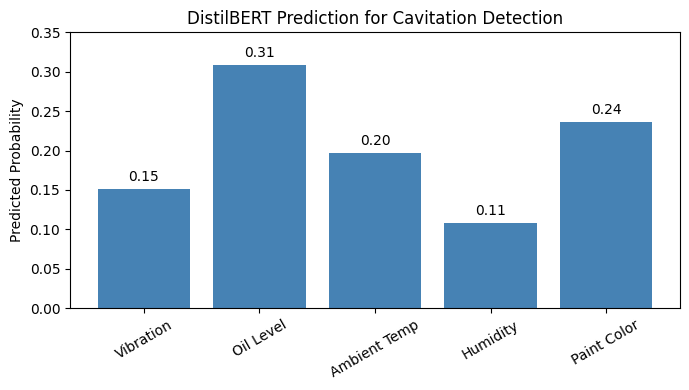

In [40]:
import matplotlib.pyplot as plt

# Sensor options and predicted probabilities
sensors = ["Vibration", "Oil Level", "Ambient Temp", "Humidity", "Paint Color"]
probs = [0.1510, 0.3081, 0.1965, 0.1082, 0.2362]

plt.figure(figsize=(7,4))

bars = plt.bar(sensors, probs, color="steelblue")

plt.ylabel("Predicted Probability")
plt.title("DistilBERT Prediction for Cavitation Detection")

plt.ylim(0, 0.35)

plt.xticks(rotation=30)

# Add probability labels above bars
for bar, p in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{p:.2f}",
             ha='center')

plt.tight_layout()

# Save for LaTeX
plt.savefig("distilbert_prediction_example.png", dpi=300)

plt.show()

In [27]:
# Testing model 2
verified_sensors = test_model(
    model_2,
    tokenizer,
    sample_question,
    mode="verification",
    threshold=0.5
)

print(f"\nModel 2 thinks these are all relevant: {verified_sensors}")


--- Verification Model Test ---
[      ] Vibration: 27.70%
[      ] Oil Level: 38.33%
[      ] Ambient Temp: 30.96%
[      ] Humidity: 33.02%
[CORRECT] Paint Color: 51.75%

Model 2 thinks these are all relevant: ['Paint Color']


Model is doing less ok - it's now indecisive althought it does highlight the correct one

In [31]:
# ============================================
# TF-IDF BASELINE WITH HYPERPARAMETER TUNING
# ============================================

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# ------------------------------------------------
# 1. Convert dataset into question–option rows
# ------------------------------------------------

rows = []

for _, row in single.iterrows():
    
    asset = row["asset_name"]
    question = row["question"]
    options = row["options"]
    correct = row["correct"]
    
    for opt, label in zip(options, correct):
        
        text = f"Asset: {asset}. Question: {question}. Option: {opt}"
        
        rows.append({
            "text": text,
            "label": int(label)
        })

tfidf_df = pd.DataFrame(rows)

print("Dataset size:", tfidf_df.shape)
print("Positive class proportion:", tfidf_df["label"].mean())

# ------------------------------------------------
# 2. Train/test split (STRATIFIED)
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    tfidf_df["text"],
    tfidf_df["label"],
    test_size=0.2,
    stratify=tfidf_df["label"],   # important for class imbalance
    random_state=42
)

# ------------------------------------------------
# 3. Pipeline: TF-IDF + Logistic Regression
# ------------------------------------------------

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000))
])

# ------------------------------------------------
# 4. Hyperparameter grid
# ------------------------------------------------

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__max_features": [3000, 5000],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

# ------------------------------------------------
# 5. Grid search
# ------------------------------------------------

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Score:")
print(grid.best_score_)

# ------------------------------------------------
# 6. Evaluate best model
# ------------------------------------------------

best_model = grid.best_estimator_

preds = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, preds))

# ------------------------------------------------
# 7. Summary table for report
# ------------------------------------------------

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1]
})

print("\nModel Performance Table:")
print(results)

# ------------------------------------------------
# 8. Hyperparameter grid results
# ------------------------------------------------

grid_results = pd.DataFrame(grid.cv_results_)

results_table = grid_results[[
    "param_tfidf__ngram_range",
    "param_tfidf__max_features",
    "param_tfidf__min_df",
    "param_clf__C",
    "param_clf__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]]

results_table = results_table.sort_values("rank_test_score")

print("\nTop Hyperparameter Configurations:")
print(results_table.head(20))

# Save results for report
results_table.to_csv("tfidf_grid_results.csv", index=False)

Dataset size: (10953, 2)
Positive class proportion: 0.24349493289509724
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

Best Cross-Validation Score:
0.35390157887138385

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.56      0.65      1658
           1       0.26      0.48      0.34       533

    accuracy                           0.54      2191
   macro avg       0.51      0.52      0.49      2191
weighted avg       0.65      0.54      0.57      2191


Model Performance Table:
                          Model  Accuracy  Precision    Recall  F1 Score
0  TF-IDF + Logistic Regression  0.540393   0.259146  0.478424   0.33619

Top Hyperparameter Configurations:
   param_tfidf__ngram_range  param_tfidf__max_features  param_tfidf__min_df  \
28                   (1, 1)       

In [62]:
# Now holding out test set

# ============================================
# DISTILBERT TRAIN + TEST PIPELINE
# ============================================

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from tqdm.auto import tqdm

MODEL_NAME = "distilbert-base-uncased"


# ============================================
# 1. TRAIN / TEST SPLIT
# ============================================

train_single, test_single = train_test_split(single, test_size=0.2, random_state=42)
train_multi, test_multi = train_test_split(multi, test_size=0.2, random_state=42)

print("Single dataset sizes:", len(train_single), len(test_single))
print("Multi dataset sizes:", len(train_multi), len(test_multi))


# ============================================
# 2. DATASETS
# ============================================

train_ds_1 = SensorDataset(train_single, tokenizer, max_len=64, is_multi=False)
test_ds_1  = SensorDataset(test_single, tokenizer, max_len=64, is_multi=False)

train_ds_2 = SensorDataset(train_multi, tokenizer, max_len=64, is_multi=True)
test_ds_2  = SensorDataset(test_multi, tokenizer, max_len=64, is_multi=True)


# ============================================
# 3. DATALOADERS
# ============================================

train_loader_1 = DataLoader(train_ds_1, batch_size=4, shuffle=True)
test_loader_1  = DataLoader(test_ds_1, batch_size=4)

train_loader_2 = DataLoader(train_ds_2, batch_size=16, shuffle=True)
test_loader_2  = DataLoader(test_ds_2, batch_size=16)


# ============================================
# 4. REINITIALIZE MODELS
# ============================================

model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)
model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1).to(device)


# Freeze base transformer for faster CPU training
for param in model_1.distilbert.parameters():
    param.requires_grad = False

for param in model_2.distilbert.parameters():
    param.requires_grad = False

print("DistilBERT base frozen. Training classification head only.")


# ============================================
# 5. TRAINING FUNCTION
# ============================================

def train_model(model, train_loader, epochs=3, lr=5e-5, is_multi=False):

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.BCEWithLogitsLoss() if is_multi else torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):

        total_loss = 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for batch in loop:

            optimizer.zero_grad()

            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']

            b_size, n_opts, seq_len = input_ids.shape

            input_ids = input_ids.view(-1, seq_len).to(device)
            attention_mask = attention_mask.view(-1, seq_len).to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if not is_multi:
                logits = logits.view(b_size, n_opts)
            else:
                logits = logits.view(-1)
                labels = labels.view(-1)

            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

    return model


# ============================================
# 6. TRAIN MODELS
# ============================================

print("\nTraining Selection Model (Model 1)...")

model_1 = train_model(
    model_1,
    train_loader_1,
    epochs=8,
    lr=5e-5,
    is_multi=False
)


print("\nTraining Verification Model (Model 2)...")

model_2 = train_model(
    model_2,
    train_loader_2,
    epochs=8,
    lr=5e-5,
    is_multi=True
)


# ============================================
# 7. EVALUATION FUNCTION
# ============================================

def evaluate_model(model, loader, is_multi=False):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']

            b_size, n_opts, seq_len = input_ids.shape

            input_ids = input_ids.view(-1, seq_len).to(device)
            attention_mask = attention_mask.view(-1, seq_len).to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            if not is_multi:

                logits = logits.view(b_size, n_opts)
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())

            else:

                logits = logits.view(-1)
                probs = torch.sigmoid(logits)

                preds = (probs > 0.5).int()

                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.view(-1).cpu().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1


# ============================================
# 8. TEST SET EVALUATION
# ============================================

print("\nEvaluating Selection Model on TEST set...")

acc, prec, rec, f1 = evaluate_model(model_1, test_loader_1, is_multi=False)

print("DistilBERT Selection Model")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)


Single dataset sizes: 2133 534
Multi dataset sizes: 4503 1126


/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inferen

DistilBERT base frozen. Training classification head only.

Training Selection Model (Model 1)...


Epoch 1: 100%|█████████████████████| 534/534 [01:30<00:00,  5.90it/s, loss=1.56]


Epoch 1 Average Loss: 1.5877


...

Epoch 7: 100%|████████████████████| 282/282 [04:02<00:00,  1.16it/s, loss=0.676]


Epoch 7 Average Loss: 0.6683


Epoch 8: 100%|████████████████████| 282/282 [04:08<00:00,  1.14it/s, loss=0.669]


Epoch 8 Average Loss: 0.6670

Evaluating Selection Model on TEST set...


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model_1.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_1:

        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        b_size, n_opts, seq_len = input_ids.shape

        input_ids = input_ids.view(-1, seq_len).to(device)
        attention_mask = attention_mask.view(-1, seq_len).to(device)

        outputs = model_1(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.view(b_size, n_opts)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted")
recall = recall_score(all_labels, all_preds, average="weighted")
f1 = f1_score(all_labels, all_preds, average="weighted")

print("DistilBERT Selection Model (TEST SET)")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nDetailed Classification Report")
print(classification_report(all_labels, all_preds))

DistilBERT Selection Model (TEST SET)
Accuracy: 0.3389513108614232
Precision: 0.33037912059812813
Recall: 0.3389513108614232
F1: 0.33418356744948263

Detailed Classification Report
              precision    recall  f1-score   support

           0       0.41      0.44      0.42       137
           1       0.46      0.50      0.48       147
           2       0.27      0.24      0.26       103
           3       0.21      0.20      0.20        84
           4       0.11      0.10      0.10        63

    accuracy                           0.34       534
   macro avg       0.29      0.29      0.29       534
weighted avg       0.33      0.34      0.33       534



In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model_2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_2:

        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        b_size, n_opts, seq_len = input_ids.shape

        input_ids = input_ids.view(-1, seq_len).to(device)
        attention_mask = attention_mask.view(-1, seq_len).to(device)
        labels = labels.view(-1).to(device)

        outputs = model_2(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits.view(-1)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("DistilBERT Verification Model (TEST SET)")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nDetailed Classification Report")
print(classification_report(all_labels, all_preds))

DistilBERT Verification Model (TEST SET)
Accuracy: 0.6003552397868561
Precision: 1.0
Recall: 0.0008880994671403197
F1: 0.001774622892635315

Detailed Classification Report
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75      3378
         1.0       1.00      0.00      0.00      2252

    accuracy                           0.60      5630
   macro avg       0.80      0.50      0.38      5630
weighted avg       0.76      0.60      0.45      5630

